# Функции (3 балла)

##1.1

Постройте график функции и её производной первого порядка. Также найдите точки экстремума функции, отметьте их на графике другим цветом. Вычисления проведите вручную и приложите скрин расчетов.

$f(x) = (x^2-2x)ln(x)-1.5x^2+4x$


Производная функции $f(x) = (x^2-2x)\ln(x) - 1.5x^2 + 4x$:

$$f'(x) = (2x-2)\ln(x) + \frac{x^2-2x}{x} - 3x + 4 = (2x-2)\ln(x) + x - 2 - 3x + 4 = 2(x-1)(\ln x - 1)$$

Приравниваем к нулю:

$$2(x-1)(\ln x - 1) = 0 \quad \Rightarrow \quad x_1 = 1, \quad x_2 = e \approx 2.718$$

При $x < 1$: $f'(x) > 0$ (возрастает) → $x_1 = 1$ — **локальный максимум**  
При $1 < x < e$: $f'(x) < 0$ (убывает) → $x_2 = e$ — **локальный минимум**

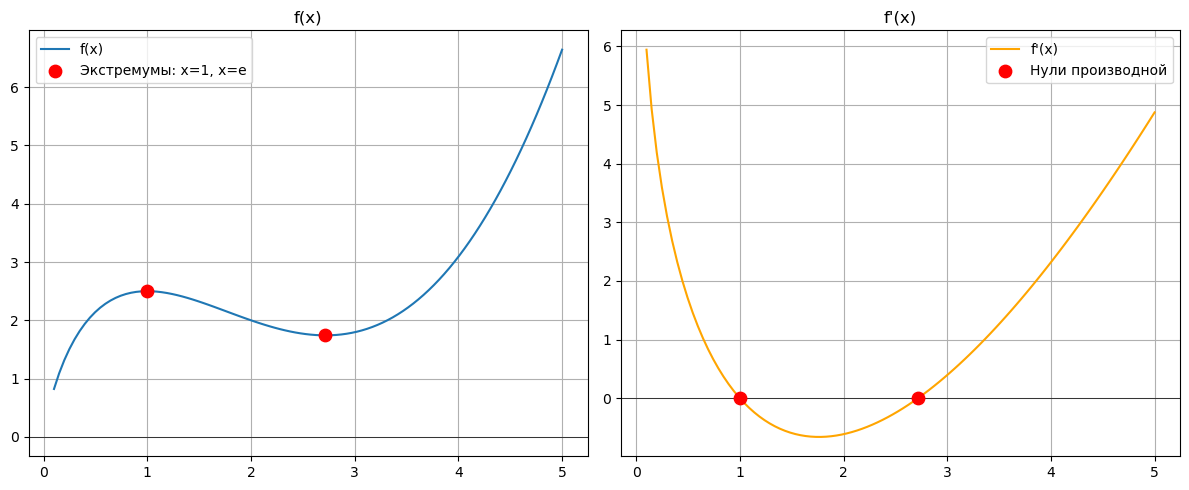

x₁ = 1.000,   f(x₁) = 2.5000  → локальный максимум
x₂ = e ≈ 2.7183, f(x₂) = 1.7420  → локальный минимум


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def f(x):
    return (x**2 - 2*x) * np.log(x) - 1.5*x**2 + 4*x

def f_dx(x):
    # f'(x) = 2(x-1)(ln(x) - 1)
    return 2 * (x - 1) * (np.log(x) - 1)


x_values = np.linspace(0.1, 5, 100)

# Точки экстремума: x=1 (максимум) и x=e (минимум)
extrema_x = np.array([1.0, np.e])
extrema_y = f(extrema_x)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x_values, f(x_values), label='f(x)')
axes[0].scatter(extrema_x, extrema_y, color='red', zorder=5, s=80, label='Экстремумы: x=1, x=e')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('f(x)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(x_values, f_dx(x_values), color='orange', label="f'(x)")
axes[1].scatter(extrema_x, np.zeros(2), color='red', zorder=5, s=80, label='Нули производной')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title("f'(x)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"x_1 = 1.000,   f(x_1) = {f(1.0):.4f} - локальный максимум")
print(f"x_2 = e = {np.e:.4f}, f(x_2) = {f(np.e):.4f}  - локальный минимум")

##1.2

Найдите частные производные функции $f(x, y, z) = 15x^2 + exp(x^2 + y^3)*cos(z)$ с помощью [SymPy](https://www.geeksforgeeks.org/python-sympy-diff-method/)

In [ ]:
from sympy import symbols, exp, cos, diff, simplify

x, y, z = symbols('x y z')

f_sym = 15*x**2 + exp(x**2 + y**3) * cos(z)

df_dx = diff(f_sym, x)
df_dy = diff(f_sym, y)
df_dz = diff(f_sym, z)

print("f(x, y, z) =", f_sym)
print("\ndf/dx =", simplify(df_dx))
print("df/dy =", simplify(df_dy))
print("df/dz =", simplify(df_dz))

f(x, y, z) = 15*x**2 + exp(x**2 + y**3)*cos(z)

∂f/∂x = 2*x*(exp(x**2 + y**3)*cos(z) + 15)
∂f/∂y = 3*y**2*exp(x**2 + y**3)*cos(z)
∂f/∂z = -exp(x**2 + y**3)*sin(z)


##2

Не всегда значения функций возможно рассчитать напрямую, однако их можно вычислить приближенно, используя, например, ряды Тейлора. Реализуйте расчет $e^x$. Сравните значения, получаемые с различной точностью приближения (5, 10, 15), с numpy-реализацией. Постройте график, отобразив на нём все четыре линии.

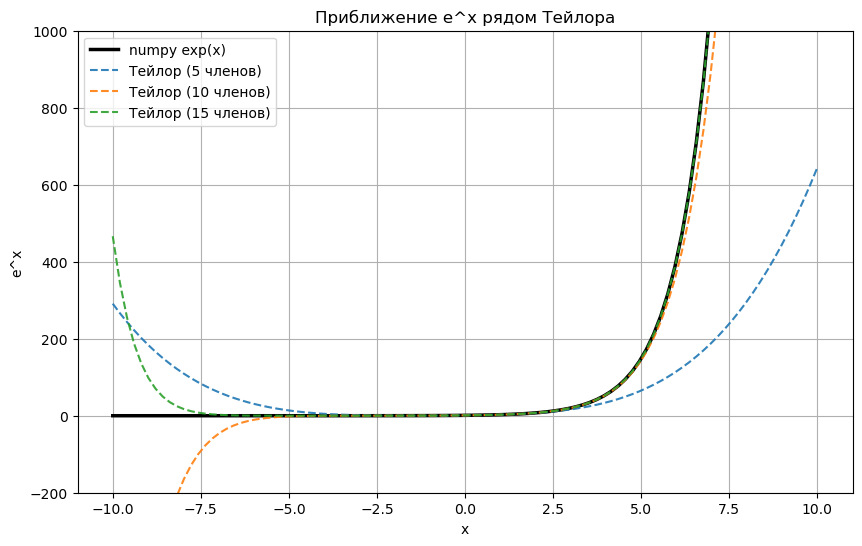

In [3]:
x_values = np.linspace(-10, 10, 100)

from math import factorial

def taylor_exp(x, n_terms):
    """Приближение e^x рядом Тейлора с n_terms членами"""
    return sum(x**n / factorial(n) for n in range(n_terms))

taylor_exp_vec = np.vectorize(taylor_exp)

y_numpy = np.exp(x_values)
y_5  = taylor_exp_vec(x_values, 5)
y_10 = taylor_exp_vec(x_values, 10)
y_15 = taylor_exp_vec(x_values, 15)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_numpy, label='numpy exp(x)', linewidth=2.5, color='black')
plt.plot(x_values, y_5,  label='Тейлор (5 членов)',  linestyle='--', alpha=0.9)
plt.plot(x_values, y_10, label='Тейлор (10 членов)', linestyle='--', alpha=0.9)
plt.plot(x_values, y_15, label='Тейлор (15 членов)', linestyle='--', alpha=0.9)
plt.ylim(-200, 1000)
plt.legend()
plt.title('Приближение e^x рядом Тейлора')
plt.xlabel('x')
plt.ylabel('e^x')
plt.grid(True)
plt.show()

##3

Рассмотрите две следующие функции, часто использующиеся как функции потерь (то есть они помогают оценить качество предсказаний модели).

$MAE (Mean\ Absolute\ Error) = \frac{1}{n} \sum_{i=1}^{n} |y_i - \widehat{y}_i|$

$MSE (Mean\ Squared\ Error) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \widehat{y}_i)^2$

Письменно ответьте на вопросы:

1. Какая проблема присуща MAE с точки зрения дифференцирования?

2. Если в качестве $\widehat{y}_i$ всегда будет предсказываться константное значение, каким оно должно быть, чтобы минимизировать значение каждой из функций?


# Матрицы. Векторы (2 балла)

##1

Реализуйте следующие паттерны. Не используйте циклы! Все матрицы квадратные со стороной длины n. Примеры приведены для n=5.

1. Шахматная доска
```
[[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]
 ```
2. Полоса шириной 3 относительно главной диагонали
```
[[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]
 ```
3. Кайма из единиц
```
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
 ```
4. Полосы
```
[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]
 ```
5. Верхний треугольник
```
[[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]
 ```


In [4]:
n = 5

# Индексы строк и столбцов пригодятся для всех паттернов
i, j = np.indices((n, n))

# 1. Шахматная доска
chess = ((i + j) % 2).astype(float)
print("1. Шахматная доска:\n", chess)

# 2. Полоса шириной 3 относительно главной диагонали (|i - j| <= 1)
band = (np.abs(i - j) <= 1).astype(float)
print("\n2. Полоса шириной 3:\n", band)

# 3. Кайма из единиц
border = np.zeros((n, n))
border[[0, -1], :] = 1
border[:, [0, -1]] = 1
print("\n3. Кайма:\n", border)

# 4. Полосы (нечётные строки = 1)
stripes = (i % 2).astype(float)
print("\n4. Полосы:\n", stripes)

# 5. Верхний треугольник
upper = np.triu(np.ones((n, n)))
print("\n5. Верхний треугольник:\n", upper)

1. Шахматная доска:
 [[0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]
 [1. 0. 1. 0. 1.]
 [0. 1. 0. 1. 0.]]

2. Полоса шириной 3:
 [[1. 1. 0. 0. 0.]
 [1. 1. 1. 0. 0.]
 [0. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]]

3. Кайма:
 [[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

4. Полосы:
 [[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]]

5. Верхний треугольник:
 [[1. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 0. 1. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 0. 1.]]


##2

Пусть дан вектор следующего вида. Преобразуйте его, чтобы получить две матрицы: первая должна содержать одинаковые значения column-wise (столбец целиком из нулей, столбец целиком из единиц и так далее), а вторая - row-wise. Не используйте циклы.

In [5]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])  # также существуют vstack и dstack
print(vector)

[0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]


In [ ]:
n = 5
vector = np.hstack([[i for i in range(n)] for _ in range(n)])
print("Вектор:", vector)

# Column-wise: reshape --> каждый столбец j целиком состоит из значения j
col_matrix = vector.reshape(n, n)
print("\nМатрица column-wise (одинаковые значения по столбцам):\n", col_matrix)

# Row-wise: просто транспонируем --> каждая строка i целиком состоит из значения i
row_matrix = vector.reshape(n, n).T
print("\nМатрица row-wise (одинаковые значения по строкам):\n", row_matrix)

Вектор: [0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4 0 1 2 3 4]

Матрица column-wise (одинаковые значения по столбцам):
 [[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]

Матрица row-wise (одинаковые значения по строкам):
 [[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]


# Введение в PyTorch (2 балла)

С точки зрения синтаксиса PyTorch похож на NumPy, основная разница заключается в том, что данный фреймворк предназначен для автоматического расчета градиентов. [Вот тут](https://github.com/torch/torch7/wiki/Torch-for-Numpy-users) можно почитать про то, как соотносятся две эти библиотеки.

[Неплохой курс чисто про PyTorch](https://www.learnpytorch.io/)

[Документация PyTorch](https://pytorch.org/)

In [7]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torchvision
from torchvision.transforms import transforms

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import nltk
from nltk import word_tokenize, sent_tokenize
nltk.download('punkt')

ModuleNotFoundError: No module named 'torch'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

##1

1. Создайте два вещественных тензора: $a$ размером (10, 2) и $b$ размером (, 20)

2. Создайте тензор c, являющийся тензором $b$, но размера (2, 2, 5)

3. Выведите первый столбец матрицы $a$ с помощью индексации

4. Создайте тензор $d$, являющийся тензором $b$, но размера (10, 2). Произведите все арифметические операции с тензорами $a$ и $d$

In [ ]:
# Создаём два вещественных тензора: a (10, 2) и b (, 20)
a = torch.rand(10, 2)
b = torch.rand(20)

# Тензор c — это b, но размером (2, 2, 5)
c = b.reshape(2, 2, 5)
print("Форма c:", c.shape)

# Первый столбец матрицы a
print("\nПервый столбец a:\n", a[:, 0])

# Тензор d — это b размером (10, 2)
d = b.reshape(10, 2)

# Арифметические операции
print("\na + d =\n", a + d)
print("\na - d =\n", a - d)
print("\na * d =\n", a * d)
print("\na / d =\n", a / d)

## 2

In [ ]:
# Создаём тензор images (100, 200, 200, 3) — 100 цветных изображений 200x200
images = torch.zeros(100, 200, 200, 3, dtype=torch.int)

# У i-ой картинки белая полоска в строках i*2 и i*2+1 (без цикла)
idx = torch.arange(100)
rows = idx * 2
images[idx, rows]     = 255
images[idx, rows + 1] = 255

# Визуализируем несколько примеров
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for k, pic_idx in enumerate([0, 5, 49]):
    axes[k].imshow(images[pic_idx].numpy())
    axes[k].set_title(f"Картинка {pic_idx}\nПолоска на строках {pic_idx*2}–{pic_idx*2+1}")
    axes[k].axis('off')
plt.tight_layout()
plt.show()

# Средняя картинка * 70 (должна быть серой)
mean_img = images.float().mean(dim=0) * 70
plt.figure(figsize=(5, 5))
plt.imshow(mean_img.int().numpy())
plt.title("Средняя картинка × 70")
plt.axis('off')
plt.show()

1. Создайте тензор *целых чисел* `images` размерности (100, 200, 200, 3) (можно интерпретировать это как 100 картинок размера 200х200 с тремя цветовыми каналами, то есть 100 цветных изображений 200х200). Заполните его нулями  

2. Сделайте так, чтобы у $i$-ой по порядку картинки была нарисована белая полоса толщиной два пикселя в строках, которые соответствуют номеру картинки * 2. Например, у 3-ей по порядку картинки белая полоска будет занимать 6 и 7 строки, у 99 - 198 и 199. Сделать белую строку можно, записав в ячейки тензора число 255 (по всем трём каналам). Выведите несколько примеров с помощью `pyplot`  

3. Посчитайте среднее тензора `images` по 1-ой оси (по сути - средняя картинка), умножьте полученный тензор на 70. Нарисуйте с помощью `pyplot`, должна получиться серая картинка (при взятии среднего нужно привести тензор к float с помощью `.float()`, при отрисовке обратно к int с помощью `.int()`)

In [ ]:
# Среда GPU уже задана выше: device = cuda

# Тензоры a (2,3,4) и b (1,8,3) на GPU, равномерная инициализация
a_gpu = torch.empty(2, 3, 4, device=device).uniform_()
b_gpu = torch.empty(1, 8, 3, device=device).uniform_()
print("Форма a:", a_gpu.shape)
print("Форма b:", b_gpu.shape)

# Меняем форму b до (2, 3, 4) --> тензор c
c_gpu = b_gpu.reshape(2, 3, 4)
print("Форма c:", c_gpu.shape)

# Перемещаем a и c на CPU
a_cpu = a_gpu.cpu()
c_cpu = c_gpu.cpu().detach().requires_grad_(True)

# L = mean((c - a)^2), считаем градиент dL/dc
L = torch.mean((c_cpu - a_cpu) ** 2)
L.backward()

print("\nГрадиент dL/dc:\n", c_cpu.grad)

# Ручная проверка: dL/dc_i = 2*(c_i - a_i) / n
n_elem = a_cpu.numel()
grad_manual = 2 * (c_cpu.detach() - a_cpu) / n_elem
print("\nРучное вычисление:\n", grad_manual)
print("\nСовпадает с autograd:", torch.allclose(c_cpu.grad, grad_manual))

## 3

1. Смените среду выполнения на GPU (в Colab нажмите в меню сверху: `Runtime` -> `Change Runtime Type` -> `GPU`, где изначально стоит `None` (`Среда выполнение` - `Сменить среду выполнения`))

2. Объявите тензор $a$ размера (2, 3, 4) и тензор $b$ размера (1, 8, 3) на GPU, иницилизируйте их случайно равномерно (`.uniform_()`)

3. Измените форму тензора $b$, чтобы она совпадала с формой тензора $a$, получите тензор $c$.

4. Переместите тензоры $a$ и $c$ на CPU.

5. Объявите тензор `L = torch.mean((c - a) `**` 2)` и посчитайте градиент $L$ по $c$ ( то есть $\frac{\partial{L}}{\partial{c}})$. Выведите градиент $L$ по $c$. Также вычислите его вручную, чтобы проверить себя.

# Теория вероятностей (4 балла)

**Ответ:**

Медиана предпочтительнее среднего в случаях, когда распределение имеет **выбросы** или сильную **асимметрию**. Классический пример — доходы населения: несколько миллиардеров сильно завышают среднее, тогда как медиана точнее отражает «типичный» доход. Аналогично с ценами на недвижимость, временем отклика серверов или любой другой величиной, где редкие экстремальные значения искажают картину.

**Модификации для улучшения среднего:**

- **Усечённое среднее (trimmed mean)** — отбрасываем некоторый процент наименьших и наибольших значений перед расчётом среднего. Например, в фигурном катании именно так считают итоговый балл: убирают наивысшую и наинизшую оценки.
- **Винзоризация (Winsorized mean)** — вместо удаления выбросов заменяем их на граничные значения (например, всё, что выше 95-го перцентиля, приравниваем к нему).
- **Взвешенное среднее** — снижаем вес подозрительных значений вместо их полного исключения.

##1

Постройте графики плотности распределений для следующих распределений:

* Биномиальное распределение
* Геометрическое распределение
* Равномерное распределение
* Нормальное распределение
* Логнормальное распределение

Параметры распределений выберите произвольно. Подумайте, какие явления в реальном мире подчиняются тому или иному распределению.

Отобразите также следующие статистические показатели: выборочное среднее, мода, медиана, стандартное отклонение.

In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Биномиальное — число орлов при 20 бросках монеты (p=0.4)
n_b, p_b = 20, 0.4
x_b = np.arange(0, n_b + 1)
pmf_b = stats.binom.pmf(x_b, n_b, p_b)
mean_b  = stats.binom.mean(n_b, p_b)
median_b = stats.binom.median(n_b, p_b)
mode_b  = x_b[np.argmax(pmf_b)]
std_b   = stats.binom.std(n_b, p_b)

axes[0].bar(x_b, pmf_b, alpha=0.7)
axes[0].axvline(mean_b, color='red', label=f'Среднее={mean_b:.2f}')
axes[0].axvline(median_b, color='green', linestyle='--', label=f'Медиана={median_b:.0f}')
axes[0].axvline(mode_b, color='purple', linestyle=':', label=f'Мода={mode_b}')
axes[0].axvspan(mean_b - std_b, mean_b + std_b, alpha=0.15, color='red', label=f'±std={std_b:.2f}')
axes[0].set_title('Биномиальное (n=20, p=0.4)\nЧисло орлов из 20 бросков')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Геометрическое — число попыток до первого успеха (p=0.3)
p_g = 0.3
x_g = np.arange(1, 15)
pmf_g = stats.geom.pmf(x_g, p_g)
mean_g   = stats.geom.mean(p_g)
median_g = stats.geom.median(p_g)
std_g    = stats.geom.std(p_g)

axes[1].bar(x_g, pmf_g, alpha=0.7, color='orange')
axes[1].axvline(mean_g, color='red', label=f'Среднее={mean_g:.2f}')
axes[1].axvline(median_g, color='green', linestyle='--', label=f'Медиана={median_g:.0f}')
axes[1].axvline(1, color='purple', linestyle=':', label='Мода=1')
axes[1].axvspan(mean_g - std_g, mean_g + std_g, alpha=0.15, color='red', label=f'+/-std={std_g:.2f}')
axes[1].set_title('Геометрическое (p=0.3)\nЧисло попыток до первого успеха')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Равномерное — время ожидания автобуса [2, 8] мин
a_u, b_u = 2, 8
x_u = np.linspace(0, 10, 300)
pdf_u = stats.uniform.pdf(x_u, a_u, b_u - a_u)
mean_u = (a_u + b_u) / 2
std_u  = stats.uniform.std(a_u, b_u - a_u)

axes[2].plot(x_u, pdf_u, 'b-', linewidth=2)
axes[2].fill_between(x_u, pdf_u, alpha=0.3)
axes[2].axvline(mean_u, color='red', label=f'Среднее=Медиана={mean_u:.1f}')
axes[2].axvspan(mean_u - std_u, mean_u + std_u, alpha=0.15, color='red', label=f'+/-std={std_u:.2f}')
axes[2].set_title('Равномерное [2, 8]\nВремя ожидания автобуса (мин)')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

# Нормальное — рост людей (mu=175, sigma=7)
mu_n, sigma_n = 175, 7
x_n = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 300)
pdf_n = stats.norm.pdf(x_n, mu_n, sigma_n)

axes[3].plot(x_n, pdf_n, 'g-', linewidth=2)
axes[3].fill_between(x_n, pdf_n, alpha=0.3, color='green')
axes[3].axvline(mu_n, color='red', label=f'Среднее=Медиана=Мода={mu_n}')
axes[3].axvspan(mu_n - sigma_n, mu_n + sigma_n, alpha=0.15, color='red', label=f'+/-std={sigma_n}')
axes[3].set_title('Нормальное (mu=175, sigma=7)\nРост людей (см)')
axes[3].legend(fontsize=8); axes[3].grid(alpha=0.3)

# Логнормальное — доходы населения (правосторонняя асимметрия)
mu_ln, sigma_ln = 0, 0.5
x_ln = np.linspace(0.001, 5, 300)
pdf_ln = stats.lognorm.pdf(x_ln, sigma_ln, scale=np.exp(mu_ln))
mean_ln   = np.exp(mu_ln + sigma_ln**2 / 2)
median_ln = np.exp(mu_ln)
mode_ln   = np.exp(mu_ln - sigma_ln**2)
std_ln    = stats.lognorm.std(sigma_ln, scale=np.exp(mu_ln))

axes[4].plot(x_ln, pdf_ln, 'm-', linewidth=2)
axes[4].fill_between(x_ln, pdf_ln, alpha=0.3, color='purple')
axes[4].axvline(mean_ln,   color='red',    label=f'Среднее={mean_ln:.2f}')
axes[4].axvline(median_ln, color='green',  linestyle='--', label=f'Медиана={median_ln:.2f}')
axes[4].axvline(mode_ln,   color='purple', linestyle=':', label=f'Мода={mode_ln:.2f}')
axes[4].axvspan(mean_ln - std_ln, mean_ln + std_ln, alpha=0.15, color='red', label=f'+/-std={std_ln:.2f}')
axes[4].set_title('Логнормальное (mu=0, sigma=0.5)\nДоходы населения')
axes[4].legend(fontsize=8); axes[4].grid(alpha=0.3)

axes[5].axis('off')
plt.tight_layout()
plt.show()

Подумайте, в каких случаях медиана предпочтительнее среднего при расчете "средней температуры по больнице". Какие модификации можно было бы произвести для формулы среднего или для выборки, чтобы среднее значение стало более репрезентативно в подобных случаях? Напишите ответ.

##2 (2 балла)

1000 человек бросают монетку. Каждый бросил 10 раз подряд.

 1. Какова вероятность того, что хотя бы у одного человека монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?
 2. Какова вероятность того, что хотя бы у одного человека монетка выпала 8 раз подряд той же самой стороной (орлом или решкой)?
 3. Какова вероятность того, что ровно у троих человек из 1000 монетка выпала 10 раз подряд той же самой стороной (орлом или решкой)?

 Рассчитайте вероятности, а также смоделируйте ситуацию и оцените эмпирическое распределение.

In [ ]:
from scipy.stats import binom as binom_dist

# Вероятность, что один человек получил 10 одинаковых подряд (все орёл или все решка)
p_10 = 2 * (0.5 ** 10)
print(f"P(10 одинаковых за 1 серию) = 2/1024 = {p_10:.6f}")

# Хотя бы у одного из 1000 — все 10 одинаковые
p1 = 1 - (1 - p_10) ** 1000
print(f"\n1. P(хотя бы один из 1000 с 10 одинаковыми) = {p1:.4f}")

# Считаем P(серия >= 8 в 10 бросках) перебором всех 2^10 = 1024 исходов
def has_run(seq, k):
    """Есть ли в последовательности серия из k одинаковых подряд"""
    count = 1
    for t in range(1, len(seq)):
        count = count + 1 if seq[t] == seq[t - 1] else 1
        if count >= k:
            return True
    return False

favorable_8 = sum(
    has_run([(out >> t) & 1 for t in range(10)], 8)
    for out in range(2**10)
)
p_8 = favorable_8 / 2**10
print(f"\nP(серия ≥ 8 в 10 бросках) = {favorable_8}/1024 = {p_8:.6f}")

# Хотя бы у одного из 1000 — серия >= 8
p2 = 1 - (1 - p_8) ** 1000
print(f"2. P(хотя бы один из 1000 с серией >= 8) = {p2:.4f}")

# Ровно 3 из 1000 получили все 10 одинаковые (биномиальное)
p3 = binom_dist.pmf(3, 1000, p_10)
print(f"\n3. P(ровно 3 из 1000 с 10 одинаковыми) = {p3:.6f}")

# Симуляция (100 000 экспериментов)
print("\n--- Симуляция (100 000 экспериментов) ---")
np.random.seed(42)
N_sim = 100_000
n_people, n_throws = 1000, 10

results = np.random.randint(0, 2, size=(N_sim, n_people, n_throws))

# Вопрос 1: все 10 одинаковые
row_sums = results.sum(axis=2)
all_same = (row_sums == 0) | (row_sums == n_throws)
sim_p1 = np.mean(all_same.any(axis=1))
print(f"1. Симуляция = {sim_p1:.4f}  (теория = {p1:.4f})")

# Вопрос 2: серия >= 8 (считаем длины серий векторизованно)
run_len = np.ones((N_sim, n_people), dtype=int)
has_run_8 = np.zeros((N_sim, n_people), dtype=bool)
for t in range(1, n_throws):
    same = results[:, :, t] == results[:, :, t - 1]
    run_len = np.where(same, run_len + 1, 1)
    has_run_8 |= (run_len >= 8)
sim_p2 = np.mean(has_run_8.any(axis=1))
print(f"2. Симуляция = {sim_p2:.4f}  (теория = {p2:.4f})")

# Вопрос 3: ровно 3 человека с 10 одинаковыми
count_all_same = all_same.sum(axis=1)
sim_p3 = np.mean(count_all_same == 3)
print(f"3. Симуляция = {sim_p3:.6f}  (теория = {p3:.6f})")

##3

В магазин поступила новая продукция с трех предприятий. Процентный состав этой продукции следующий: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта. Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта. Если известно, что купленная продукция высшего сорта, какова вероятность, что она была куплена на втором предприятии?

Решите задачу в общем случае для N предприятий, где доля продукции каждого составляет $a_i$, а доля продукции высшего сорта на каждом составляет $b_i$. Напишите функцию, принимающую на вход два списка: a и b, а также n - номер предприятия, для которого необходимо узнать вероятность, что продукция высшего сорта была куплена именно на нём (нумерация с единицы). Функция должна возвращать две вероятности.

In [ ]:
def total_and_bayes(a, b, n):
    """
    Вычисляет полную вероятность и апостериорную вероятность по Байесу.

    a[i] — доля продукции i-го предприятия (сумма = 1)
    b[i] — доля высшего сорта на i-м предприятии
    n    — номер предприятия (нумерация с 1)

    Возвращает: (P(высший сорт), P(предприятие n | высший сорт))
    """
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)

    # Полная вероятность: P(H) = sum_i P(A_i) * P(H | A_i)
    p_top = np.sum(a * b)

    # Формула Байеса: P(A_n | H) = P(A_n) * P(H | A_n) / P(H)
    p_from_n = a[n - 1] * b[n - 1] / p_top

    return p_top, p_from_n


# Данные из задачи
a = [0.20, 0.30, 0.50]   # доли продукции предприятий
b = [0.10, 0.05, 0.20]   # доли высшего сорта

p_total, p_2 = total_and_bayes(a, b, n=2)

print(f"P(высший сорт) = {p_total:.4f}")
print(f"P(предприятие 2 | высший сорт) = {p_2:.4f}")

# Проверка: сумма байесовских вероятностей по всем предприятиям должна быть 1
print("\nАпостериорные вероятности для всех предприятий:")
total_check = 0
for i in range(1, len(a) + 1):
    _, p_i = total_and_bayes(a, b, n=i)
    print(f"P(предприятие {i} | высший сорт) = {p_i:.4f}")
    total_check += p_i
print(f"Сумма = {total_check:.4f}")

# Методы оптимизации (3 балла)



(Задание взято у Яндекса)

Дана функция $f(x) = (a\sin(x) + b\ln(x))^2 + cx^2$ и файл, содержащий пары (x, f(x)). Необходимо с точностью до трёх знаков после запятой подобрать коэффициенты a, b, c исходной функции. Для решения задачи предлагается использовать градиентный спуск и функцию потерь MSE.

P.S. на предоставленном наборе данных возможно получить MSE < 0.00001, ориентируйтесь на эту цифру.

In [ ]:
!gdown 1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3

Downloading...
From: https://drive.google.com/uc?id=1P5REbDVMtoHk_EPOaXzFWym2sMKhhbg3
To: /content/data.txt
100% 27.0k/27.0k [00:00<00:00, 14.1MB/s]


In [ ]:
with open('data.txt', 'r') as file:
    x_data = []
    y_data = []
    for para in eval(file.read()):
        x_data.append(para[0])
        y_data.append(para[1])
x_data = np.array(x_data)
y_data = np.array(y_data)

In [ ]:
# Преобразуем данные в тензоры
x_t = torch.tensor(x_data, dtype=torch.float32)
y_t = torch.tensor(y_data, dtype=torch.float32)

# Инициализируем параметры a, b, c случайно
torch.manual_seed(0)
a = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
c = torch.randn(1, requires_grad=True)

optimizer = torch.optim.Adam([a, b, c], lr=0.01)
losses = []

for epoch in range(10000):
    optimizer.zero_grad()
    y_pred = (a * torch.sin(x_t) + b * torch.log(x_t)) ** 2 + c * x_t ** 2
    loss = torch.mean((y_pred - y_t) ** 2)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (epoch + 1) % 2000 == 0:
        print(f"Эпоха {epoch+1:5d}: MSE={loss.item():.8f}  "
              f"a={a.item():.3f}  b={b.item():.3f}  c={c.item():.3f}")

print(f"\nРезультат: a={a.item():.3f}, b={b.item():.3f}, c={c.item():.3f}")
print(f"MSE = {losses[-1]:.8f}")

# Графики: динамика потерь и сравнение предсказаний с данными
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses)
axes[0].set_yscale('log')
axes[0].set_title('Динамика MSE')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE (log)')
axes[0].grid(True)

with torch.no_grad():
    y_pred_final = (a * torch.sin(x_t) + b * torch.log(x_t)) ** 2 + c * x_t ** 2

sort_idx = np.argsort(x_data)
axes[1].scatter(x_data, y_data, s=5, alpha=0.4, label='Данные')
axes[1].plot(x_data[sort_idx], y_pred_final.numpy()[sort_idx], color='red', label='Подобранная функция')
axes[1].set_title('Подбор функции')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()